In [1]:
!pip  install numpy 
!pip  install pandas
!pip intall seaborn
!pip  install matplotlib



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: unknown command "intall" - maybe you meant "install"




[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip  install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# Handeling Missing Values 

In [11]:
import  numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib as plt


In [19]:
data = pd.DataFrame({
    'Age': [25, 30, np.nan, 22, 150, 28, 30, 22, np.nan,  21],
    'Salary': [50000, 60000, 52000, np.nan, 70000, -10000, 58000, 60000, 61000, np.nan],
    'City': ['New York', 'new york', 'NY', 'Log Angles', 'Chicago', 'NYC', np.nan, 'New York', 'NY', 'Ny']
})

In [5]:
data

,Age,Salary,City
0,25.0,50000.0,New York
1,30.0,60000.0,new york
2,NaN,52000.0,NY
3,22.0,NaN,Log Angles
4,150.0,70000.0,Chicago
5,28.0,-10000.0,NYC
6,30.0,58000.0,NaN
7,22.0,60000.0,New York
8,NaN,61000.0,NY
9,21.0,NaN,Ny


In [20]:
# Detecting missing values 
data.isnull().sum()

Age       2
Salary    2
City      1
dtype: int64

Using Heatmap 


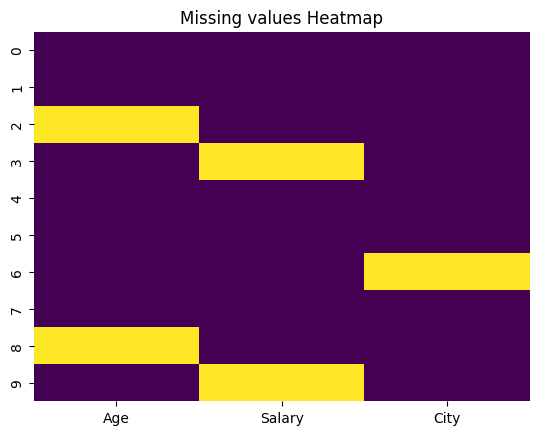

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing values Heatmap")
plt.show()

In [8]:
# Handeling missing values

# from sklearn.impute import SimpleImputer


# impute = SimpleImputer(strategy="mean")

In [9]:
# data[["Age"]] = impute.fit_transform(data[["Age"]])
# data[["Age"]]

In [22]:
from sklearn.impute import SimpleImputer

# Clean column names
data.columns = data.columns.str.strip().str.lower()

# Imputing missing values
impute = SimpleImputer(strategy='most_frequent')

# Apply
data[["city"]] = impute.fit_transform(data[["city"]])

print(data[['city']])

         city
0    New York
1    new york
2          NY
3  Log Angles
4     Chicago
5         NYC
6          NY
7    New York
8          NY
9          Ny


Step 02 :Outlier Detection 

Outlier Detection (Z-Score Method)

In [23]:
from scipy import stats

In [27]:
z_scores = np.abs(stats.zscore(data[['age', 'salary']]))
outliers_z = (z_scores > 3).any(axis=1)
data[outliers_z]

,age,salary,city


IQR (INTERQUARTILE RANGE )

In [37]:
for col in ['age', 'salary']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    data[col] = np.where(
        data[col] < lower, lower,
        np.where(data[col] > upper, upper, data[col])
    )

print(data)

    age   salary        city
0  25.0  50000.0    New York
1  30.0  60000.0    new york
2   NaN  52000.0          NY
3  22.0      NaN  Log Angles
4  42.0  70000.0     Chicago
5  28.0  38375.0         NYC
6  30.0  58000.0          NY
7  22.0  60000.0    New York
8   NaN  61000.0          NY
9  21.0      NaN          Ny
